# Notebook 08 — Inference Pipeline
**CIS6035 IHMS — Somerset Mirissa Beach Hotel**

Exports a clean, self-contained `predict_occupancy()` function that:
- Loads the best model artifact from `models/best_model.pkl`
- Accepts a start date and number of days
- Returns a list of dicts: `[{date, predicted_occupancy, lower, upper}, ...]`

This function is imported verbatim by `backend/app/services/prediction_service.py`.

In [2]:
import json
import joblib
import numpy as np
import pandas as pd
from datetime import date, timedelta
from pathlib import Path

MODELS_DIR = Path('../models')

# Load metadata
with open(MODELS_DIR / 'model_metadata.json') as f:
    metadata = json.load(f)

winner = metadata['winner']
print(f'Winner model: {winner.upper()}')
print(json.dumps(metadata, indent=2))

Winner model: SARIMA
{
  "winner": "sarima",
  "test_rmse": 0.0944,
  "test_mae": 0,
  "all_models": {
    "arima": {
      "rmse": 0.1018,
      "mae": 0.0793,
      "mape": 15.75
    },
    "sarima": {
      "rmse": 0.0944,
      "mae": 0.0736,
      "mape": 14.65
    },
    "prophet": {
      "rmse": 0.103,
      "mae": 0.0825,
      "mape": 14.81
    }
  },
  "trained_on": "2024-12-31",
  "evaluated_on": "2025-12-31"
}


In [3]:
# Load best model
artifact = joblib.load(MODELS_DIR / 'best_model.pkl')
model = artifact['model']
print(f'Model loaded: {type(model).__name__}')

# Re-save as Prophet JSON (version-agnostic, avoids pickle compatibility issues)
if winner == 'prophet':
    from prophet.serialize import model_to_json
    with open(MODELS_DIR / 'best_model_prophet.json', 'w') as f:
        f.write(model_to_json(model))
    print('Saved best_model_prophet.json')

Model loaded: SARIMAXResultsWrapper


In [4]:
# Define the canonical inference function

def predict_occupancy(start_date, days=30):
    """
    Generate a day-level occupancy forecast.
    
    Args:
        start_date: date object or ISO string 'YYYY-MM-DD'
        days: number of days to forecast (default 30)
    
    Returns:
        List of dicts: [
            {"date": date, "predicted_occupancy": float,
             "lower": float|None, "upper": float|None},
            ...
        ]
    """
    if isinstance(start_date, str):
        start_date = date.fromisoformat(start_date)
    
    winner_model = metadata.get('winner', 'prophet').lower()
    
    if winner_model == 'prophet':
        last_train_date = model.history_dates.max().date()
        periods_needed = (start_date - last_train_date).days + days
        future_df = model.make_future_dataframe(periods=max(periods_needed, days), freq='D')
        future_df = future_df[future_df['ds'] >= pd.Timestamp(start_date)]
        forecast = model.predict(future_df)
        
        result = []
        for _, row in forecast.iterrows():
            result.append({
                'date': row['ds'].date(),
                'predicted_occupancy': float(np.clip(row['yhat'], 0, 1)),
                'lower': float(np.clip(row.get('yhat_lower', row['yhat']), 0, 1)),
                'upper': float(np.clip(row.get('yhat_upper', row['yhat']), 0, 1)),
            })
        return result[:days]
    
    else:  # ARIMA or SARIMA
        forecast_vals = model.forecast(steps=days)
        return [
            {
                'date': start_date + timedelta(days=i),
                'predicted_occupancy': float(np.clip(val, 0, 1)),
                'lower': None,
                'upper': None,
            }
            for i, val in enumerate(forecast_vals)
        ]

In [5]:
# Test the function
from datetime import date

results = predict_occupancy(start_date=date.today(), days=30)

print(f'Forecast generated: {len(results)} days')
print('\nFirst 5 predictions:')
for r in results[:5]:
    print(f"  {r['date']}  occupancy={r['predicted_occupancy']:.3f}  "
          f"lower={r['lower']}  upper={r['upper']}")

# Validate output structure
assert len(results) == 30
for r in results:
    assert 'date' in r
    assert 'predicted_occupancy' in r
    assert 0 <= r['predicted_occupancy'] <= 1
    assert 'lower' in r
    assert 'upper' in r
print('\nAll assertions passed.')

Forecast generated: 30 days

First 5 predictions:
  2026-03-08  occupancy=0.824  lower=None  upper=None
  2026-03-09  occupancy=0.803  lower=None  upper=None
  2026-03-10  occupancy=0.813  lower=None  upper=None
  2026-03-11  occupancy=0.800  lower=None  upper=None
  2026-03-12  occupancy=0.801  lower=None  upper=None

All assertions passed.


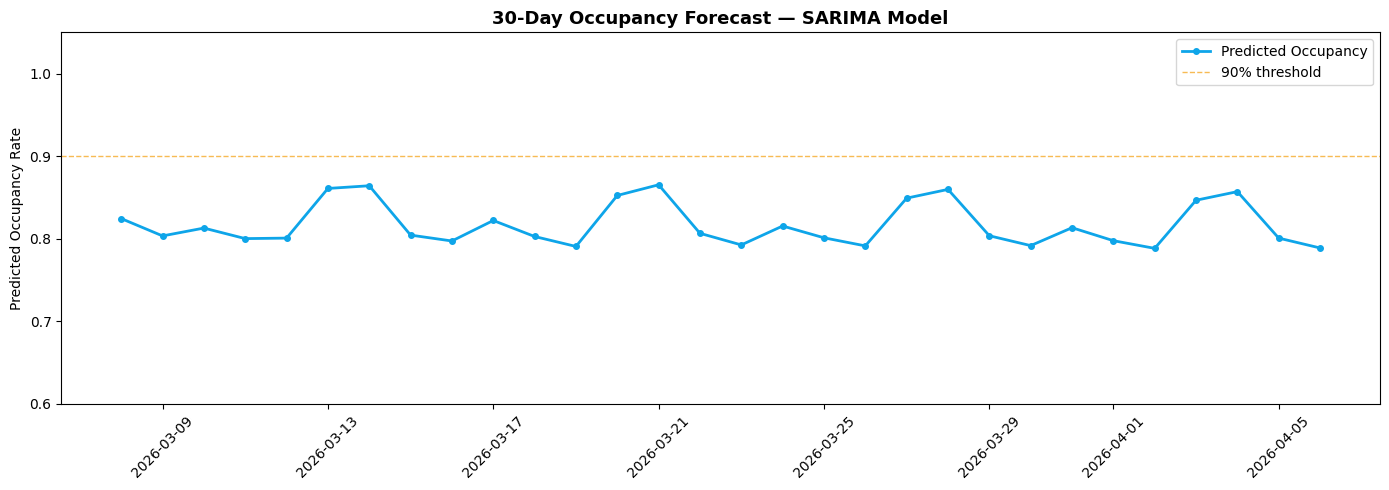

Average predicted occupancy: 0.817 (81.7%)
Peak days (≥90%): 0

Inference pipeline validated. Ready for production deployment.


In [6]:
import matplotlib.pyplot as plt

dates  = [r['date'] for r in results]
preds  = [r['predicted_occupancy'] for r in results]
lowers = [r['lower'] for r in results]
uppers = [r['upper'] for r in results]

plt.figure(figsize=(14, 5))
plt.plot(dates, preds, 'o-', color='#0ea5e9', linewidth=2, markersize=4, label='Predicted Occupancy')
if lowers[0] is not None:
    plt.fill_between(dates, lowers, uppers, color='#bae6fd', alpha=0.4, label='90% CI')
plt.axhline(0.9, color='#f59e0b', linestyle='--', alpha=0.7, linewidth=1, label='90% threshold')
plt.title(f'30-Day Occupancy Forecast — {winner.upper()} Model', fontsize=13, fontweight='bold')
plt.ylabel('Predicted Occupancy Rate')
plt.ylim(0.6, 1.05)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('../docs/figures/08_inference_output.png', dpi=150, bbox_inches='tight')
plt.show()

avg_occ = sum(preds) / len(preds)
print(f'Average predicted occupancy: {avg_occ:.3f} ({avg_occ*100:.1f}%)')
print(f'Peak days (≥90%): {sum(1 for p in preds if p >= 0.9)}')
print(f'\nInference pipeline validated. Ready for production deployment.')